### Test if the distribution is matched properly
Three ways:

1) Plot phase space. If the distribution is mathed there shouls be no filamentation. 

2) Plot evolution of the rms bunch length and momentum spread over the turns. if the distribution is matched perfectly their values should not change. 

3) In the presence of CC plot the induced closed orbit at different turns. If the distribution is matched the closed orbit should be the same. 

In [1]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Plotting parameters
params = {'legend.fontsize': 25,
          'figure.figsize': (18, 15),
          'axes.labelsize': 25,
          'axes.titlesize': 25,
          'xtick.labelsize': 25,
          'ytick.labelsize': 25,
          'image.cmap': 'jet',
          'lines.linewidth': 5,
          'lines.markersize': 8,
          'font.family': 'sans-serif'}

plt.rc('text', usetex=False)
plt.rc('font', family='serif')
plt.rcParams.update(params)

In [3]:
track_with = 'sixtracklib' # 'pysixtrack'

In [4]:
df_1 =  pd.read_pickle('/afs/cern.ch/work/n/natriant/private/{}_example_crabcavity/output/tbt.pkl'.format(track_with)) 

In [5]:
np.std(df_1['sigma'][0]) # initial rms bunch length

0.16721201256328494

### Plot longitudinal phase space

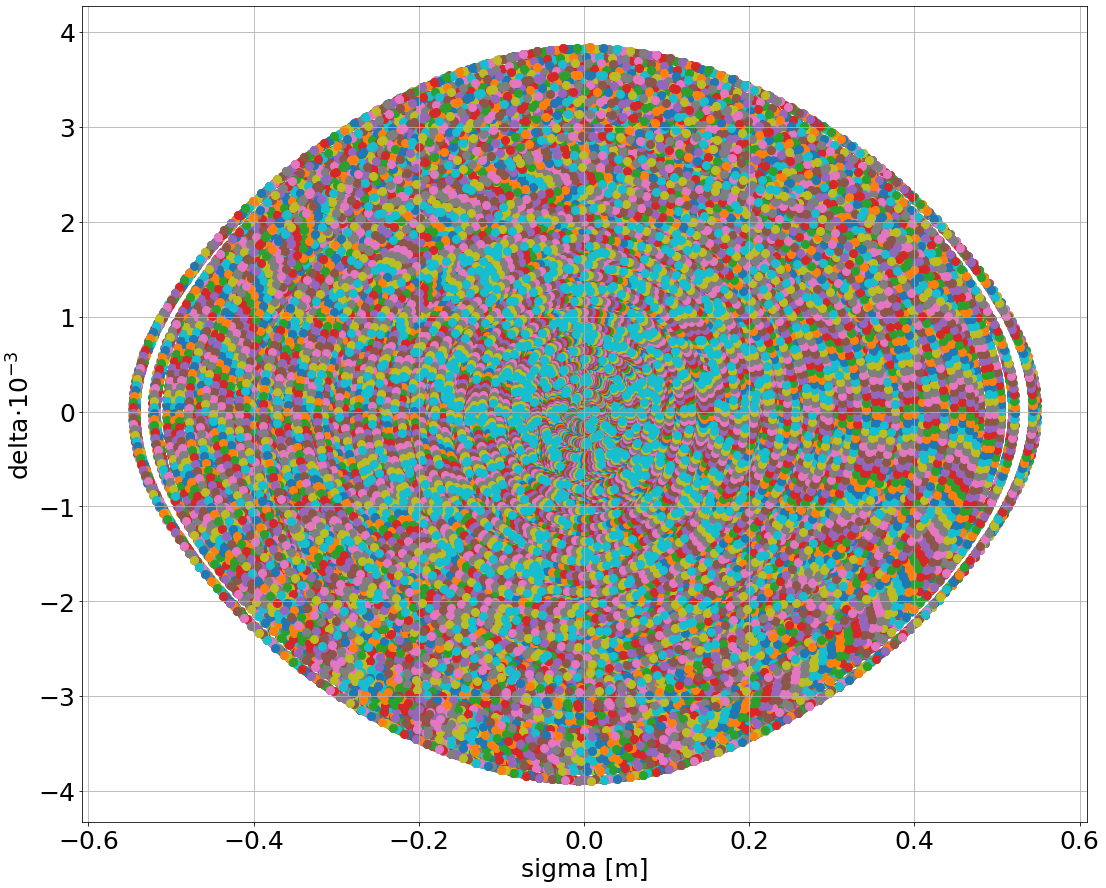

In [11]:
turns_list = np.arange(0,1000)
for turn in turns_list:
    plt.scatter(df_1['sigma'][turn], np.array(df_1['delta'][turn])*1e3)
plt.xlabel('sigma [m]')
plt.ylabel('delta'+ r'$\cdot 10^{-3}$')
plt.grid()
#plt.savefig('longitudinal_phas_space_sps26GeV_Vrf2MV_VCC3MV_lag90_ramp200.png')

### Plot evolution of rms bunch length and rms momentum spread

In [12]:
rms_bunch_length = []
rms_momentum_spread = []

for turn in turns_list:
    rms_bunch_length.append(np.std(df_1['sigma'][turn]))
    rms_momentum_spread.append(np.std(df_1['delta'][turn]))

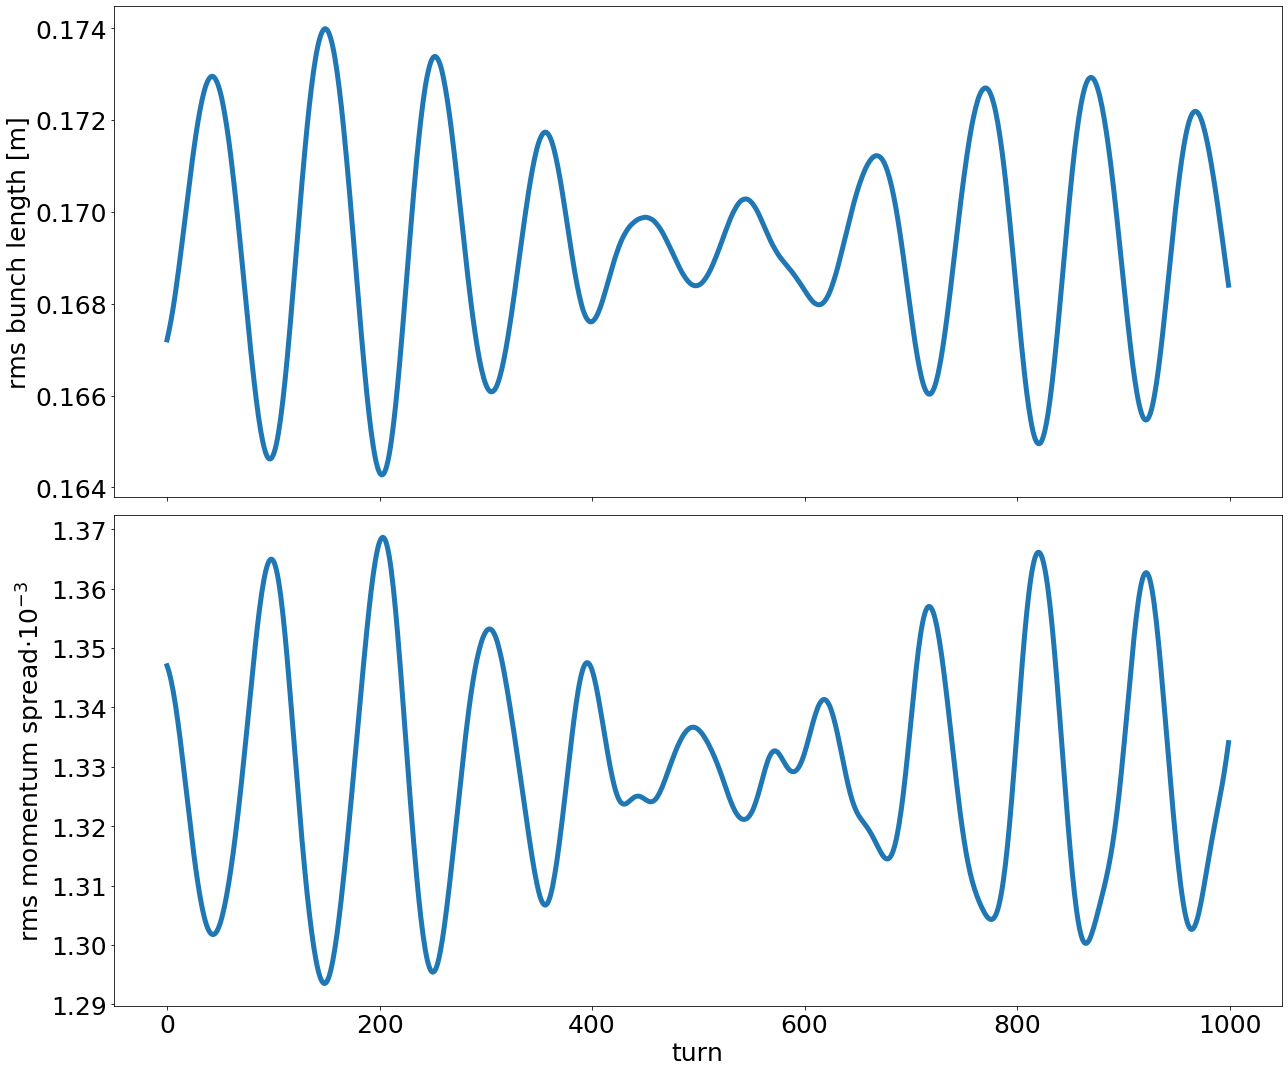

In [13]:
fig, axes = plt.subplots(2,1, sharex=True)
axes[0].plot(turns_list, rms_bunch_length)
axes[1].plot(turns_list, np.array(rms_momentum_spread)*1e3)
axes[0].set_ylabel('rms bunch length [m]')
axes[1].set_ylabel('rms momentum spread'+r'$\cdot 10^{-3}$')
plt.xlabel('turn')
plt.tight_layout()
#plt.savefig('rms_bunch_length_and_delta_vs_turns_sps26GeV_Vrf2MV_VCC3MV_lag90_ramp200.png')

### Plot induced closed orbit (in the presence of CC)

In [14]:
# Estimate the kick theoretically, according to rf_multipole_sanity_check_pysixtrack_001.ipynb
E_0 = 26e9 # total energy of the reference particle [eV]
clight = 299792458 # speed of light [m/s]
V_CC = 3e6 # V
f_CC = 400e6 # Hz
ps = 0# 90.  # phase of the cavity
k = 2 * np.pi * f_CC / clight # wavenumber of the cavity

# create a sample distribution
n_particles = 1000.
start, stop = -0.6, 0.6
step = (stop-start)/n_particles
initial_sigmas = np.arange(start, stop, step)

# lattice parameters
beta_y = 27.46384921 # start of the lattice
beta_y_CC1 =  76.07315729 # CC1
Qy = 26.18
muy = + 4.05373914

# transverse kick from the CC
delta_py_CC = V_CC * np.sin(ps + k * np.array(initial_sigmas))/E_0

# closed orbit at the begining of the lattice (dumping point)
y_co_CC = (np.sqrt(beta_y*beta_y_CC1)) * np.array(delta_py_CC)*np.cos(2*np.pi*muy - np.pi*Qy)/ (2*np.sin(np.pi*Qy))

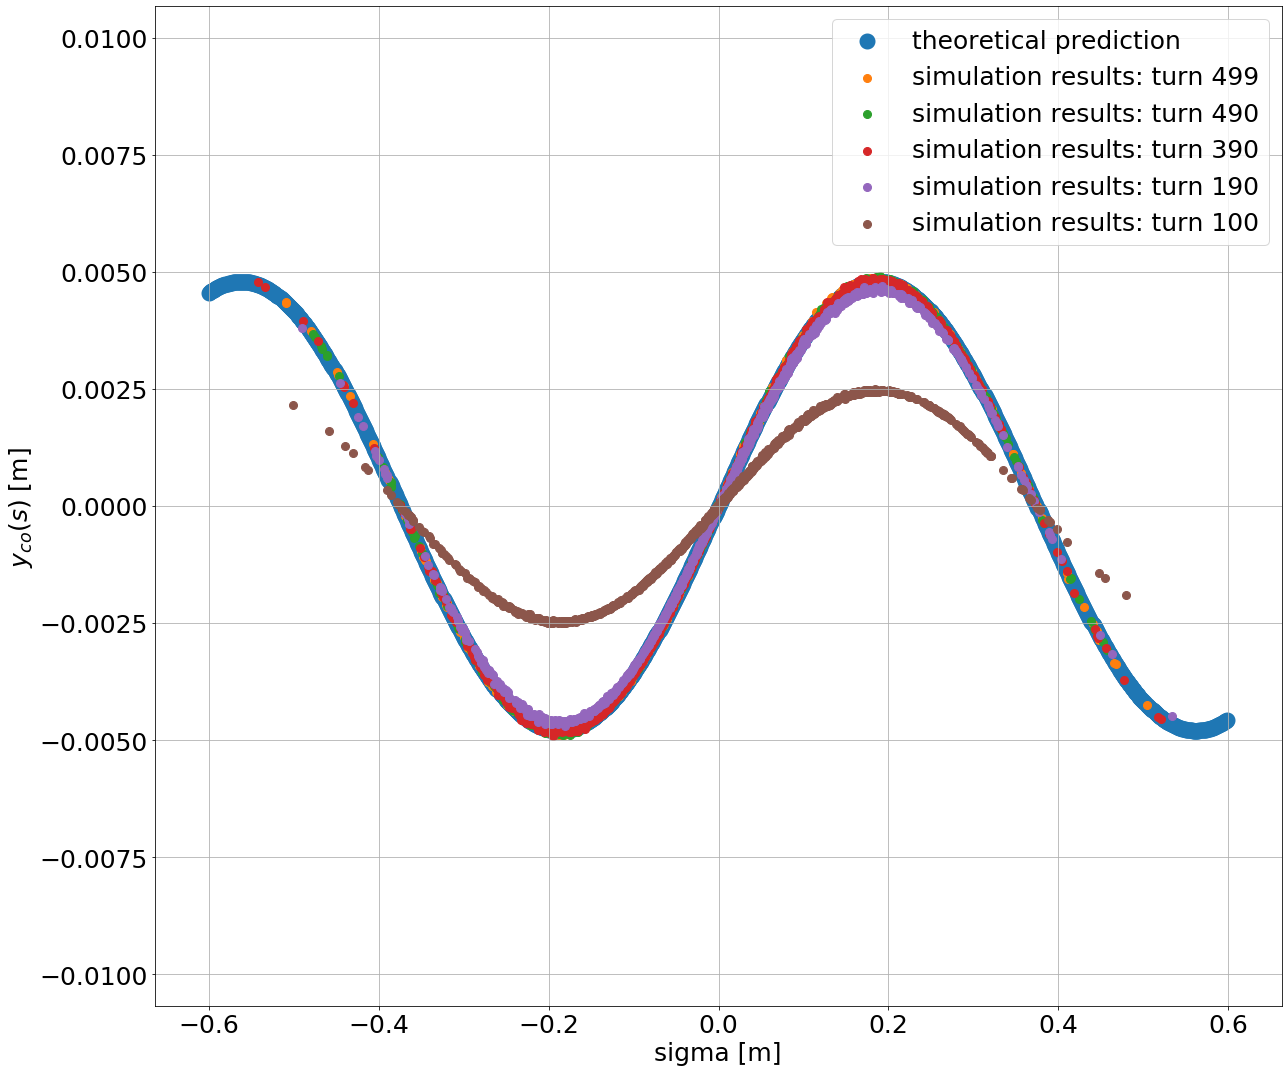

In [15]:
test_turns = [499, 490, 390, 190, 100]
plt.scatter(initial_sigmas, y_co_CC, label = 'theoretical prediction', linewidth = 8)
for turn in test_turns:
    plt.scatter(df_1['sigma'][turn], df_1['y'][turn], label ='simulation results: turn {}'.format(turn))
plt.xlabel('sigma [m]')
plt.ylabel(r'$y_{co}(s)$ [m] ')
plt.grid()
plt.legend()
plt.tight_layout()
#plt.savefig('./closed_orbit_distortion_sps26GeV_Vrf2MV_VCC3MV_lag90_ramp200.png')